## Make images

In [1]:
import radmc3d_tools
import radmc3dPy
import numpy as np
import matplotlib.pyplot as plt

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")
# Don't touch. 

###### REMEMBER TO CHECK PATH ########

## Creating the dust_temp.dat file

In [3]:
## instead of running radmc3d mctherm (which takes a long time and is not relevant for our wavelength range) we define the 
## dust_temperature.dat file on our own.
path = "/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims"

#"""

"""
If something doesn't work, rerun this after trying main(). This updates the density file, 
which is necessary to find the right size for the dust temperature file
"""
rho = np.fromfile(f"{path}/dust_density.inp", sep="\n")  # adjust separator if needed
n_cells = len(rho)-3

# Create dust temperatures
dust_temp = np.ones(shape=n_cells)
dust_temp *= 10  # arbitrary temperature 10K

# Write to file in RADMC-3D format
with open(f"{path}/dust_temperature.dat", "w") as f:
    f.write("1\n")            # number of dust species
    f.write(f"{n_cells}\n")   # number of cells
    f.write("1\n")            # number of components (usually 1)
    # Now write the temperatures in scientific notation
    for temp in dust_temp:
        f.write(f" {temp:.6e}\n")
#"""

In [4]:
dust_temp= np.fromfile(f"{path}/dust_temperature.dat", sep="\n ")
print(dust_temp)

[1.0000e+00 6.1056e+06 1.0000e+00 ... 1.0000e+01 1.0000e+01 1.0000e+01]


In [5]:
from radmc3dPy.image import makeImage, readImage, plotImage

In [6]:
import os
import sys

class silence_stdout_stderr:
    def __enter__(self):
        # Save original FDs
        self.old_stdout = os.dup(1)
        self.old_stderr = os.dup(2)

        # Redirect both to /dev/null
        self.devnull = os.open(os.devnull, os.O_WRONLY)
        os.dup2(self.devnull, 1)
        os.dup2(self.devnull, 2)

    def __exit__(self, *args):
        # Restore original FDs
        os.dup2(self.old_stdout, 1)
        os.dup2(self.old_stderr, 2)

        os.close(self.devnull)
        os.close(self.old_stdout)
        os.close(self.old_stderr)

# K-Band: 2.2µm, fiducial model, dens=1

From the article: We find an average inclination of 43°.99 ± 0°.87
and position angle of 358°.7 ± 1°.1 in the H band, and
45°.86 ± 1°.27 and 359°.3 ± 2°.3 in the Ks band, respectively

In [25]:
incl = 45.0
posang = 356.+90
npix = 200
sizeau = 200.
phi= 90 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

In [26]:
import subprocess
import os
from radmc3dPy.image import makeImage

path = '/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_sigslop_0_2gen'
sigma_dust_2d = main(path, dens=0.05)
# Save original environment
with silence_stdout_stderr():
    makeImage(npix=npix, incl=incl, wav=wav_K, sizeau=sizeau, phi=phi, posang=posang,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K0 = readImage()

1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.06912608418792082
  FlaringIndex in RADMC-3D model at R0 = 0.24934156881001246
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp


KeyboardInterrupt: 

In [ ]:
plotImage(image_K0,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K0,saturate=0.15)

# H-Band: 1.65µm

In [ ]:
import subprocess
import os
from radmc3dPy.image import makeImage

# Save original environment
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=0.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H0 = readImage()

In [ ]:

plotImage(image_H0, log=True, maxlog=20)

# Images for all models

Maybe add an exponential cutoff at the edge?

In [7]:
incl = 45.0
posang = 357.+90
npix = 400
sizeau = 800. # 800
phi_ang= 180 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

In [8]:
path_start = f"/pfs/10/work/hd_cu284-work2/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen","fargo_sigslop_1.5_2gen", ]
print(path_endings)
sigslopes = np.array([1,1,1,1,1,0,0.5,-2,1.5])



paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])


['fargo_fiducial_2gen', 'fargo_high_mass_2gen', 'fargo_low_mass_2gen', 'fargo_high_visc_2gen', 'fargo_low_visc_2gen', 'fargo_sigslop_0_2gen', 'fargo_sigslop_0.5_2gen', 'fargo_sigslop_-2_2gen', 'fargo_sigslop_1.5_2gen']


In [18]:
dens_list = np.ones(len(path_endings))*1
dens_list[5] = 0.028944000000109972/0.1056456000004014
dens_list[6] = 0.028944000000109972/0.05286511414157853
dens_list[7] = 0.028944000000109972/2.5930712520098522
dens_list[8] = 0.028944000000109972/0.018126968430822298
#### Or, if same disk mass and not same sigma_0 at planet desired
#dens_list=0.1*ms/(57**2*(r_max**(2-sigslopes)-r_min**(2-sigslopes))/(2-sigslopes)*57**sigslop*au**2*sigma_0*2*np.pi #g/cm²)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0) # g/cm²
print("sigma_0 at dens=1:", sigma_0, "g/cm²")
print("Minimum masss solar nebula:", 1.7e3* (57)**(-3/2), "g/cm²")

r_min_au = 0.3*r0
r_max_au = 7*r0

for it,sigslop in enumerate(sigslopes):
    #M = dens_list[it]*57**2*(r_max**(2-sigslop)-r_min**(2-sigslop))/(2-sigslop)*57**sigslop*au**2*sigma_0*2*np.pi #g/cm²
    M = dens_list[it]*(r_max_au**(2-sigslop)-r_min_au**(2-sigslop))/(2-sigslop)*r0**sigslop*sigma_0*2*np.pi #g/cm²
    print(f"##### {path_endings[it]} #####")
    print(f"Estimate for disk mass: {M/ms} solar masses")




sigma_0 at dens=1: 1.8807016570478543 g/cm²
Minimum masss solar nebula: 3.950359661422061 g/cm²
##### fargo_fiducial_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_high_mass_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_low_mass_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_high_visc_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_low_visc_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_sigslop_0_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_sigslop_0.5_2gen #####
Estimate for disk mass: 0.02894400000010998 solar masses
##### fargo_sigslop_-2_2gen #####
Estimate for disk mass: 0.028944000000109972 solar masses
##### fargo_sigslop_1.5_2gen #####
Estimate for disk mass: 0.02894400000010997 solar masses


In [19]:
from altered_setup import main

images_K=[]
images_H=[]
sigmeans = []


for i,path in enumerate(paths[:]):
    sigma_dust_2d = main(path, dens=dens_list[i], scat_mode=1)

    with silence_stdout_stderr():
        makeImage(npix=npix, incl=incl, wav=wav_K, sizeau=sizeau, phi=phi_ang, posang=posang,
                  pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)
    
    image = readImage()
    images_K.append(image)

    """
    with silence_stdout_stderr():
        makeImage(npix=npix, incl=incl, wav=wavH, sizeau=sizeau, phi=phi, posang=posang,
                  pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)
    
    image = readImage()
    images_H.append(image)
    """    
    sigma_mean = np.mean(sigma_dust_2d[0], axis=1)
    sigmeans.append(sigma_mean)

    #np.save("radmc3d_imgs_redone/images_K_all_mass_0_03_scat_mode_1",images_K, allow_pickle=True)
    #np.save("images_H",images_H, allow_pickle=True)
    #np.save("radmc3d_imgs_redone/sigmameans_all_mass_0_03_scat_mode_1",sigmeans, allow_pickle=True)
    #np.save("radmc3d_imgs_redone/dens_dens_all_mass_0_03_scat_mode_1", dens_list, allow_pickle=True)

1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.06912608418792082
  FlaringIndex in RADMC-3D model at R0 = 0.24934156881001246
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp
Executing RADMC-3D Command:
radmc3d image npix 400 incl 45.0 sizeau 800.0 lambda 2.2 phi 180 posang 447.0 pointau 0.0 0.0 0.0 fluxcons nostar
Reading image.out
1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.06912608418792082
  FlaringIndex in RADMC-3D model at R0 = 0.24934156881001246
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RA

# Images (without companion, scatmode 1)

In [16]:
incl = 45.0
posang = 356.+90
npix = 200
sizeau = 400. # 800
phi_ang= 180 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen","fargo_sigslop_1.5_2gen", ]
sigslopes = np.array([1,1,1,1,1,0,0.5,-2,1.5])



paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])


In [11]:
import numpy as np
from radmc3dPy.image import makeImage, plotImage

images_K = np.load("radmc3d_imgs_redone/images_K_dens_0_5.npy", allow_pickle=True)
sigmeans = np.load("radmc3d_imgs_redone/sigmameans_dens_0_5.npy", allow_pickle=True)



Text(0.5, 1.0, 'Dust density')

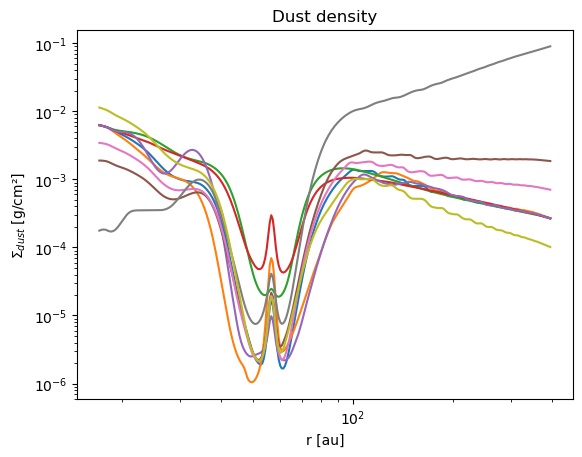

In [12]:
path = paths[-1]
r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
for i,path in enumerate(paths):
    plt.plot(r_list*57, sigmeans[i], label=f"{path[43:-5]}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.title("Dust density")

#########################
/fargo_fiducial images:
#########################


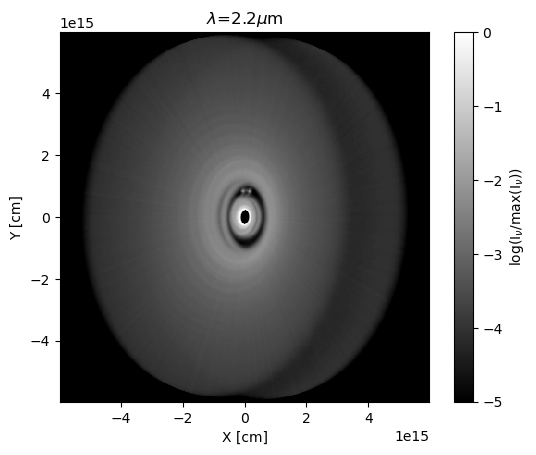

In [11]:
for i,path in enumerate(paths[:1]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    plotImage(images_K[i],log=True, maxlog=5)#saturate=0.1)#
    #result = plotImage(images_K[i],saturate=0.01)


In [9]:
print(path_endings)

['fargo_fiducial_2gen', 'fargo_high_mass_2gen', 'fargo_low_mass_2gen', 'fargo_high_visc_2gen', 'fargo_low_visc_2gen', 'fargo_sigslop_0_2gen', 'fargo_sigslop_0.5_2gen', 'fargo_sigslop_-2_2gen', 'fargo_sigslop_1.5_2gen']


#########################
fargo_fiducial images:
#########################


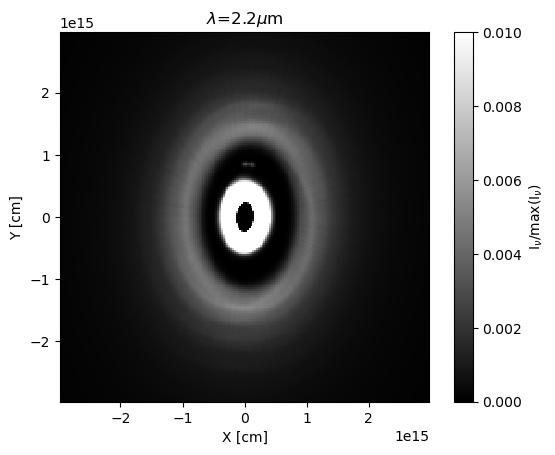

<Figure size 640x480 with 0 Axes>

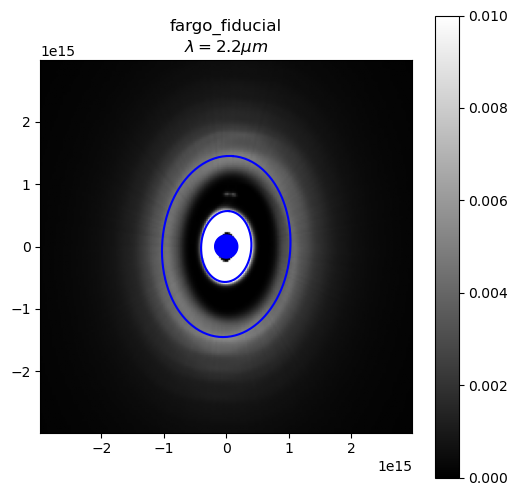

#########################
fargo_high_mass images:
#########################


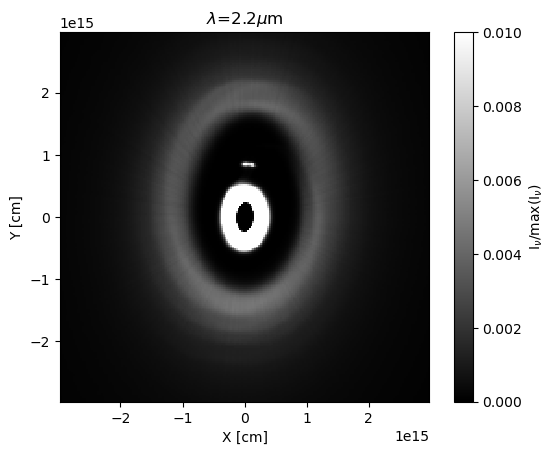

<Figure size 640x480 with 0 Axes>

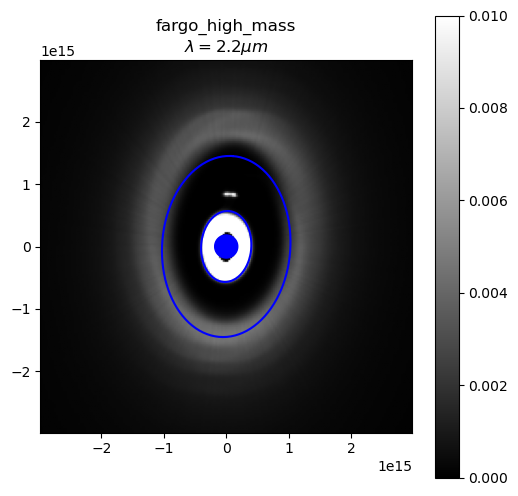

#########################
fargo_low_mass images:
#########################


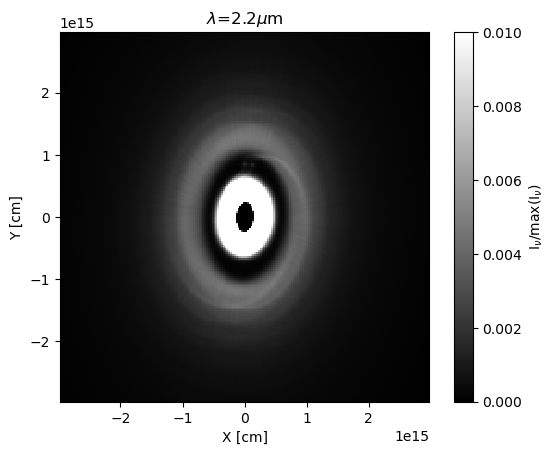

<Figure size 640x480 with 0 Axes>

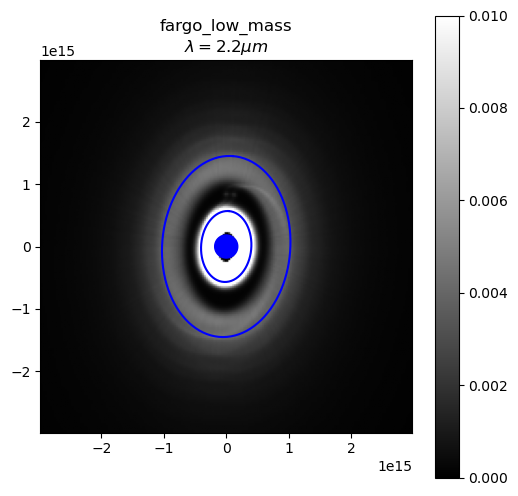

#########################
fargo_high_visc images:
#########################


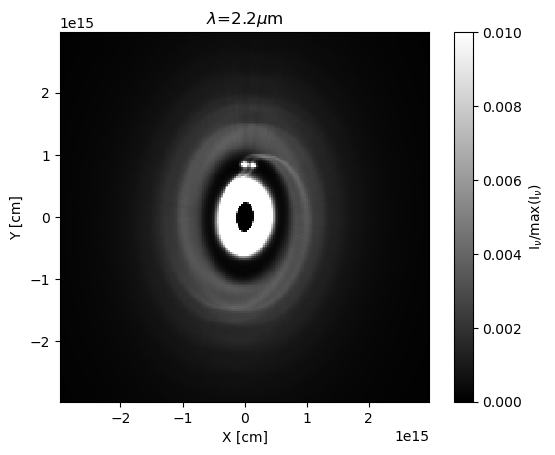

<Figure size 640x480 with 0 Axes>

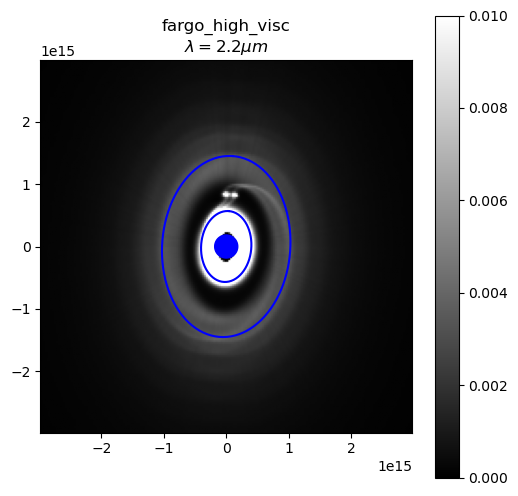

#########################
fargo_low_visc images:
#########################


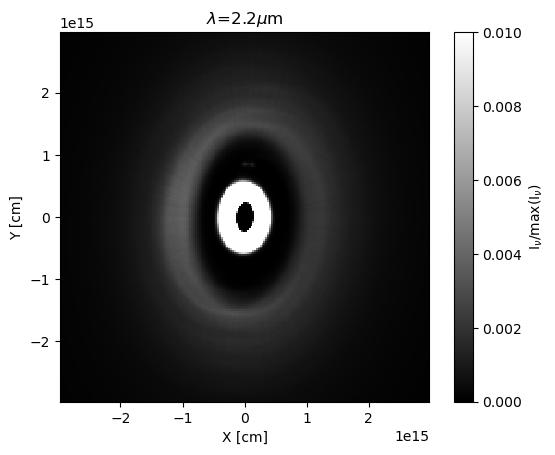

<Figure size 640x480 with 0 Axes>

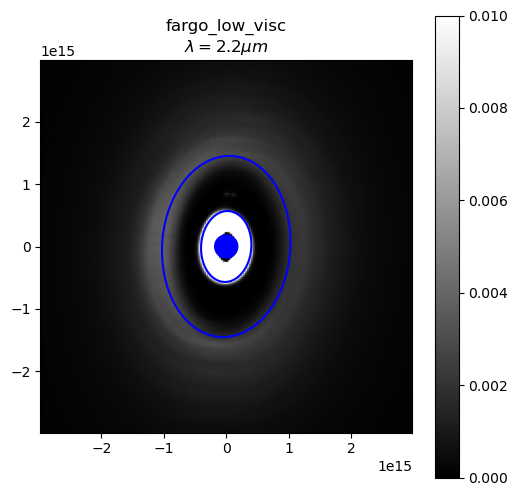

#########################
fargo_sigslop_0 images:
#########################


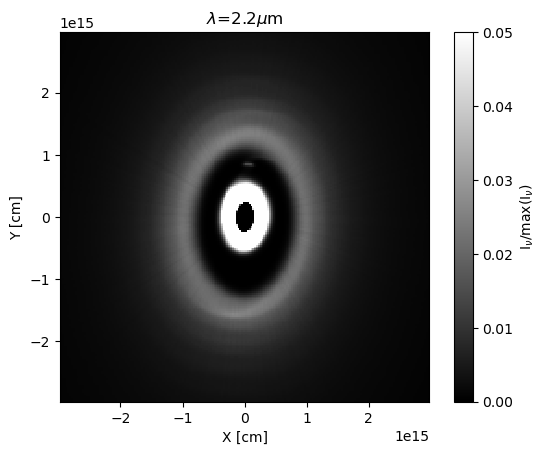

<Figure size 640x480 with 0 Axes>

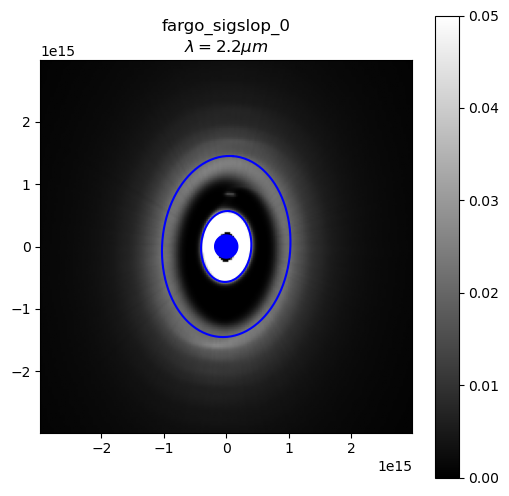

#########################
fargo_sigslop_0.5 images:
#########################


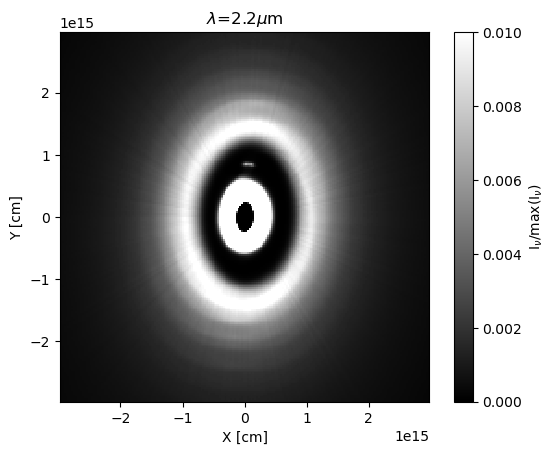

<Figure size 640x480 with 0 Axes>

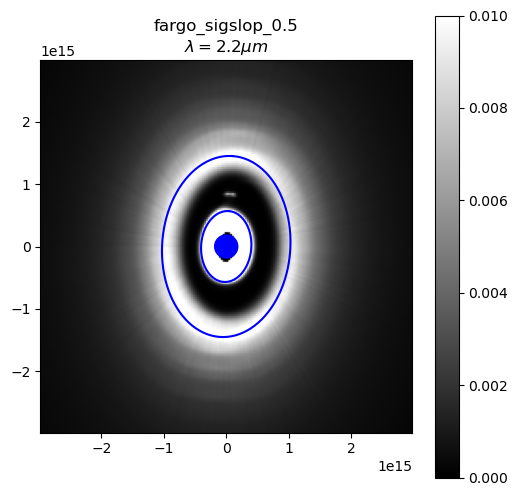

#########################
fargo_sigslop_-2 images:
#########################


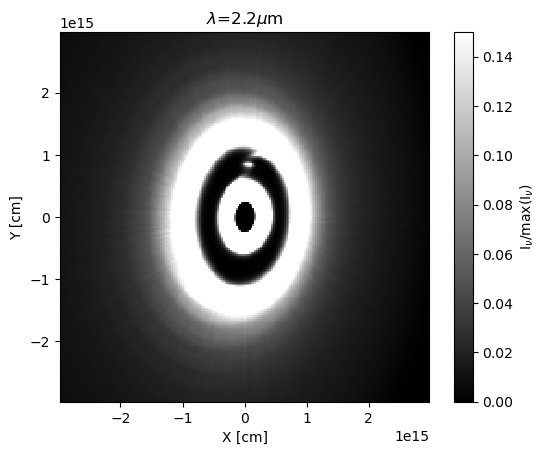

<Figure size 640x480 with 0 Axes>

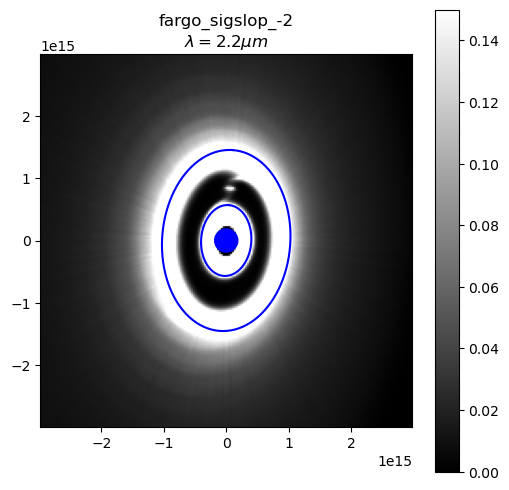

#########################
fargo_sigslop_1.5 images:
#########################


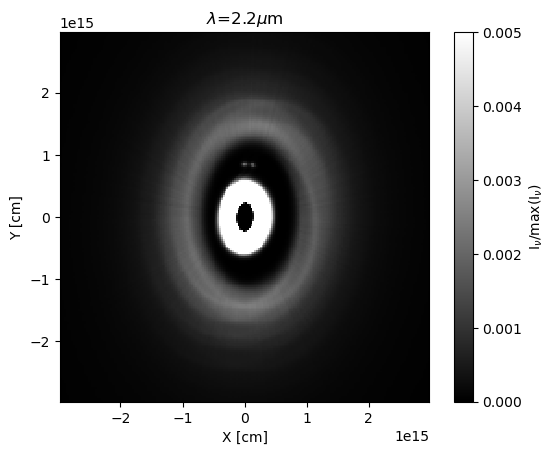

<Figure size 640x480 with 0 Axes>

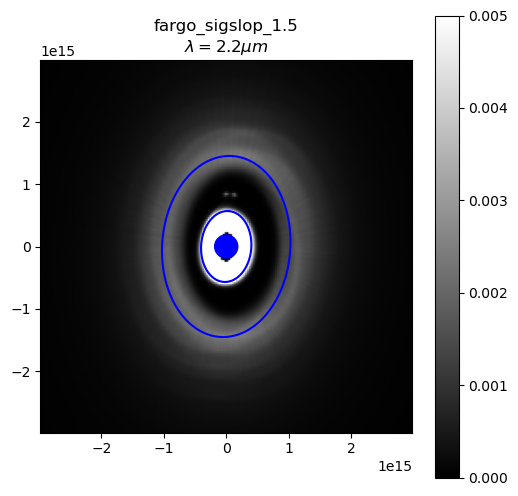

<Figure size 640x480 with 0 Axes>

In [17]:
saturate = list(0.01*np.ones(len(paths)))

saturate[5] = 0.05
saturate[7] = 0.15
saturate[8] = 0.005

for i,path in enumerate(paths[:]):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #result = plotImage(images_K[i],log=True, maxlog=10)
    
    result = plotImage(images_K[i],saturate=saturate[i])#, fig=fig,ax=ax)# showfig=False)
    img = result["implot"]
    plt.savefig(f"img/radmc3d_{path[43:-5]}_close.png")

    data = img.get_array()
    extent = img.get_extent()
    cmap = img.get_cmap()
    norm = img.norm


    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(
        data,
        extent=extent,
        cmap=cmap,
        norm=norm,
    )
    phi = np.linspace(0,2*np.pi,200)
    posang_rad = (-posang+90)/180*np.pi
    #316, 164, 97, and 38
    au  = 1.49598e13 
    for ri in [38,97,146,316][:2]:
        r = ri*au
        x = r*np.sin(phi)*np.sin(incl/360*2*np.pi)
        y= r*np.cos(phi)

        xx = x*np.cos(posang_rad) + y*np.sin(posang_rad)
        yy = -x*np.sin(posang_rad) + y*np.cos(posang_rad)
        ax.plot(xx, yy, c="blue", zorder=10)

    ## The coronagraph
    r = 185e-3/2*133.3 * au # 185 mas diameter, 133.3 pc distance
    xx = r * np.sin(phi)
    yy = r*np.cos(phi)
    ax.fill(xx,yy, c="blue", hatch="/")
    
    plt.colorbar(ax.images[0], ax=ax)
    plt.title(f"{path[43:-5]}\n$\\lambda = 2.2 \\mu m$")
    plt.show()
    plt.savefig(f"img/radmc3d_{path[43:-5]}_close_up_rings.png")
    
    #print(posang, posang_rad, np.cos(posang_rad))

In [18]:
"""
for i,path in enumerate(paths):
    print(f"#########################\n{path[43:-5]} images:#########################")
    plotImage(images_H[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_H[i],saturate=0.005)
"""

'\nfor i,path in enumerate(paths):\n    print(f"#########################\n{path[43:-5]} images:#########################")\n    plotImage(images_H[i],log=True, maxlog=10)#saturate=0.1)#\n    plotImage(images_H[i],saturate=0.005)\n'

#########################
fargo_low_mass images:
#########################


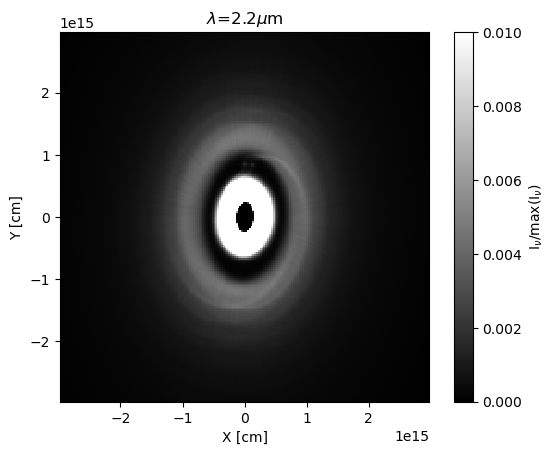

#########################
fargo_fiducial images:
#########################


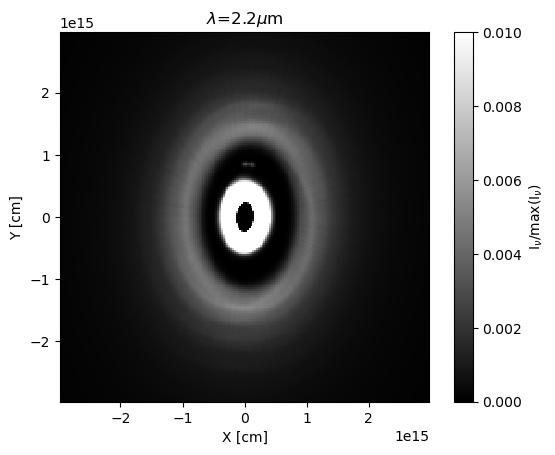

#########################
fargo_high_mass images:
#########################


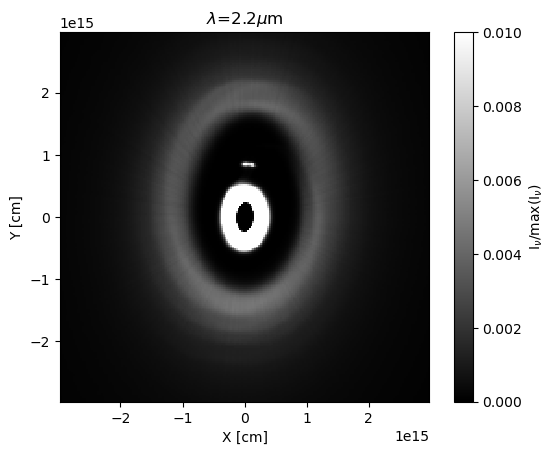

Text(0.5, 1.0, 'Different masses')

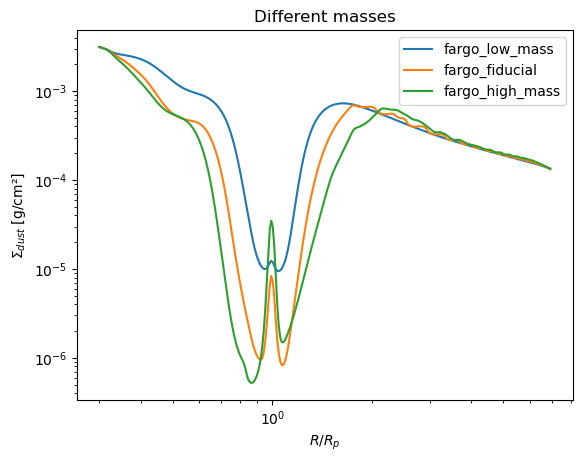

In [19]:

index_for_mass=[2,0,1]

for i in index_for_mass:
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=0.01)

for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,sigmeans[i], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Different masses")

### Notes planet mass
- lower planet mass -> shallower, narrower gap
- higher planet mass -> deeper gap, but only to some point
- higher planet mass -> Rossby wave very visible!
- in all images spirals somewhat visible

#########################
fargo_low_visc images:
#########################


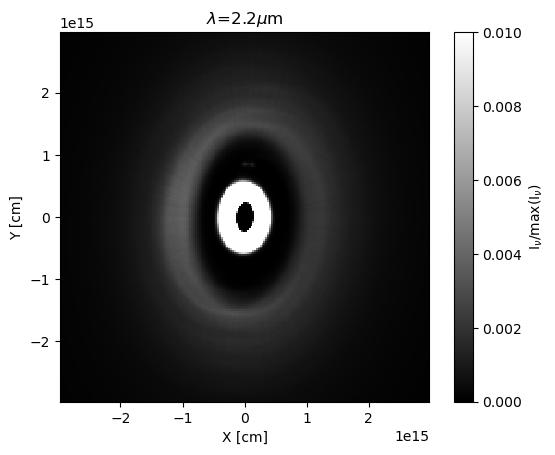

#########################
fargo_fiducial images:
#########################


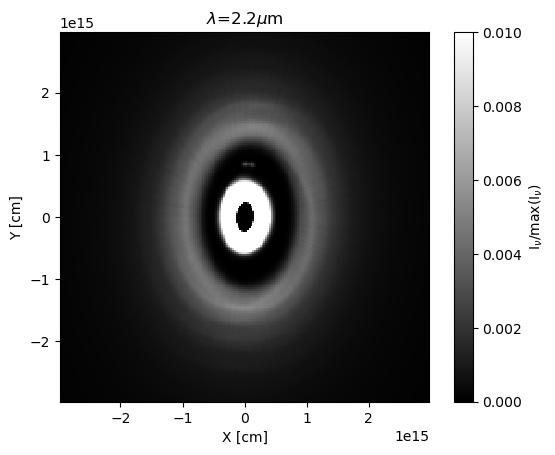

#########################
fargo_high_visc images:
#########################


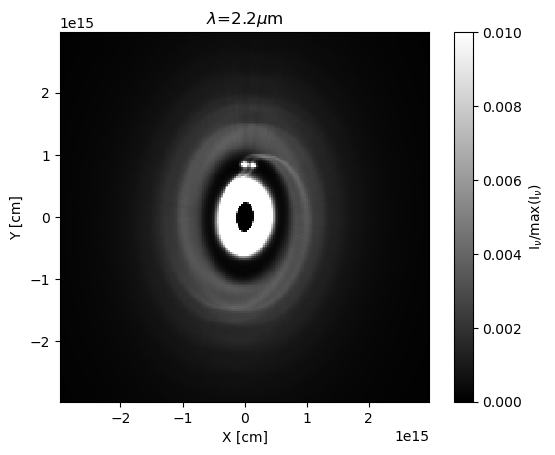

Text(0.5, 1.0, 'Different viscosities')

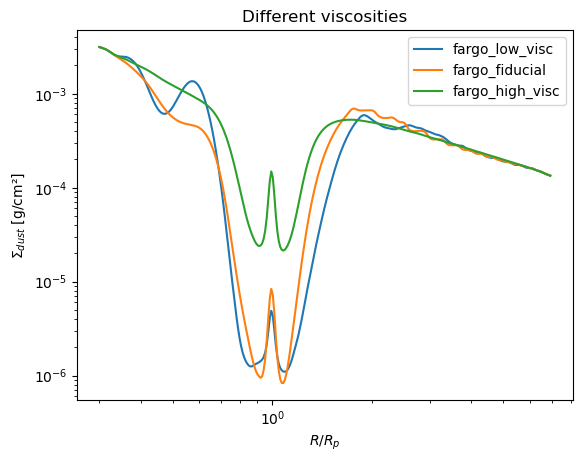

In [14]:
index_for_visc=[4,0,3]

for i in index_for_visc:
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=0.01)

for i in index_for_visc:
    path = paths[i]
    plt.plot(r_list,sigmeans[i], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Different viscosities")

### Notes viscosity
- higher viscosity -> shallower gap
- lower viscosity -> deeper gap, but only to some point
- higher viscosity -> spirals more visible, apparently??
- lower viscosity -> Rossby wave (?), outer edge of gap slightly egg-shaped

#########################
fargo_sigslop_1.5 images:
#########################


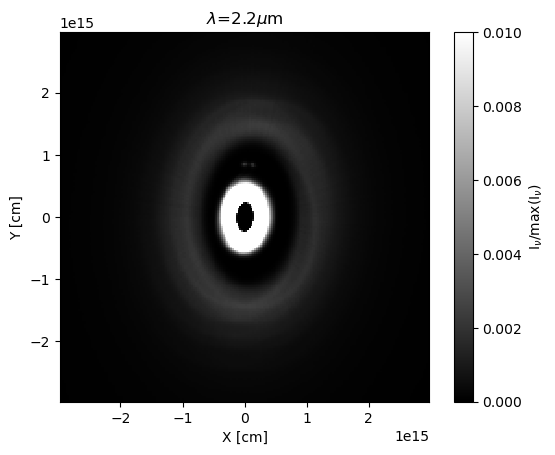

#########################
fargo_fiducial images:
#########################


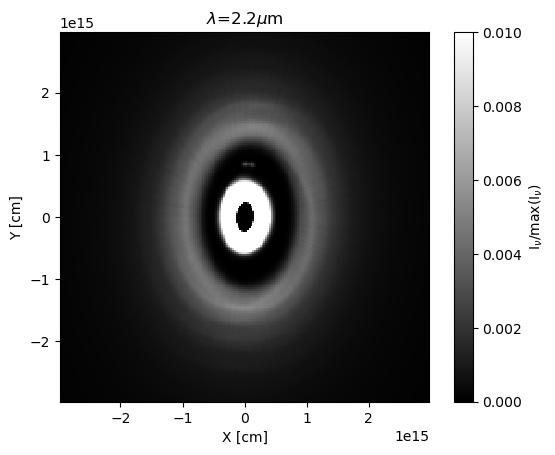

#########################
fargo_sigslop_0.5 images:
#########################


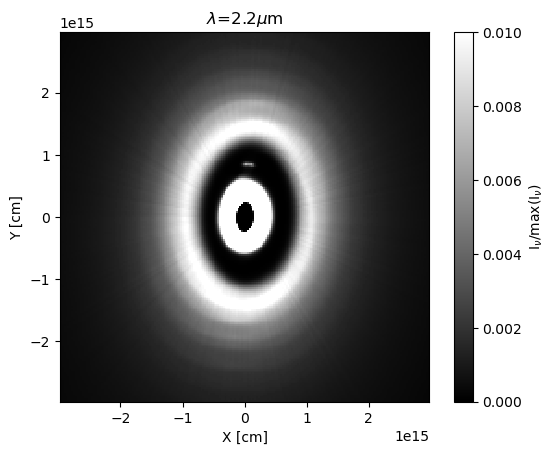

#########################
fargo_sigslop_0 images:
#########################


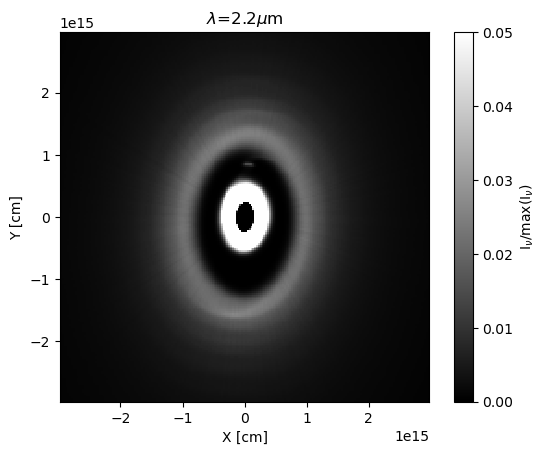

Text(0.5, 1.0, 'Different sigma slopes')

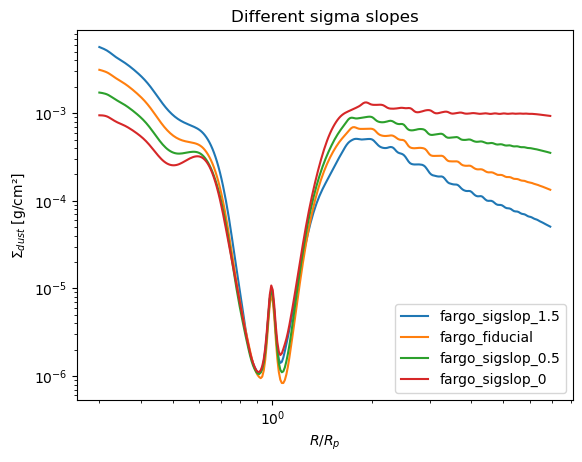

In [15]:
index_for_sigslop = [8,0,6,5]#,7]
saturate_list = [0.01,0.01,0.01,0.05]#np.ones(4)

for it,i in enumerate(index_for_sigslop):
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=saturate_list[it])

for i in index_for_sigslop:
    path = paths[i]
    plt.plot(r_list,sigmeans[i], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Different sigma slopes")

### Notes sigma slope
- for (very weird) sigma slope of -2, back of disk is visible at the edge. Also, disk scatters much better at large r.
- gap depth does (weakly!) depend on sigma slope
- 